# Chuẩn bị

**Cài đặt các Thư viện sử dụng**

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt dataFrame**

In [6]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**

In [7]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

# Khám phá dữ liệu

**Xem thông tin dữ liệu**

In [8]:
data_df.head(5)

,title,text,label
0,Cấm biển di dân khỏi vùng nguy hiểm từ Quảng N...,Các tỉnh ven biển phía Bắc cấp tập di dân tạm ...,0
1,Hội Cựu Công an nhân dân là thành viên Mặt trậ...,Ủy ban Trung ương Mặt trận Tổ quốc (MTTQ) Việt...,0
2,Thêm 30 cá thể hổ và sư tử ở Vườn thú Mỹ Quỳnh...,Ngày 2-10 bà Đinh Thị Phương Khanh Phó Giám đố...,0
3,Đà Lạt: Lũ cuốn trôi ô tô 1 người mất tích,Khoảng 13 giờ 30 phút ngày 2-10 tại đập tràn t...,0
4,Kiên Giang: Cất bốc 19 hài cốt liệt sĩ tại huy...,Ngày 2-10 thông tin từ Bộ Chỉ huy quân sự tỉnh...,0


**Xáo trộn dữ liệu**

In [9]:
data_df=data_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [10]:
data_df.head(5)

,title,text,label
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1
1,Biển Đông: Trung Quốc âm mưu chia rẽ Việt Nam ...,Nguồn hình ảnh BBC/Virma Simonette Philippines...,1
2,Mất căn cước công dân ở nước ngoài tôi có được...,Tôi đã từng làm căn cước công dân (CCCD). Cách...,0
3,Đường dây dùng trẻ em phục vụ khiêu dâm bị phá...,Đồng NaiCác nghi phạm mua bán sử dụng người dư...,0
4,Phạm Minh Hoàng: Hội Thánh Truyền Giáo Phục Hư...,Tình hình dịch Covid-19 tại Việt Nam đang rất ...,1


**Mô tả của dữ liệu**

In [11]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


In [12]:
data_df.describe().round(1)

,label
count,12600.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,1.0


**Kích thước của DataFrame và danh sách các tên cột**

In [13]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

(12600, 3)
['title', 'text', 'label']


**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [14]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
3


**Kiểm tra dữ liệu có bị lặp**

In [15]:
dup=data_df.index.duplicated().sum()
dup

0

**Kiểm tra dữ liệu có bị thiếu**

In [16]:
data_df['title'].isnull().sum()

0

In [17]:
data_df['text'].isnull().sum()

0

In [18]:
data_df['label'].isnull().sum()

0

**Kiểm tra loại dữ liệu**

In [19]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [20]:
open_object_dtype(data_df['title'])

{str}

In [21]:
open_object_dtype(data_df['text'])

{str}

In [22]:
open_object_dtype(data_df['label'])

{int}

**Kiểm tra số từ của title và text**

In [23]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [24]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,12600.000000,12600.000000
mean,13.281905,913.570556
std,4.446797,828.093960
min,1.000000,52.000000
25%,10.000000,384.000000
50%,14.000000,699.000000
75%,16.000000,1174.000000
max,47.000000,15495.000000


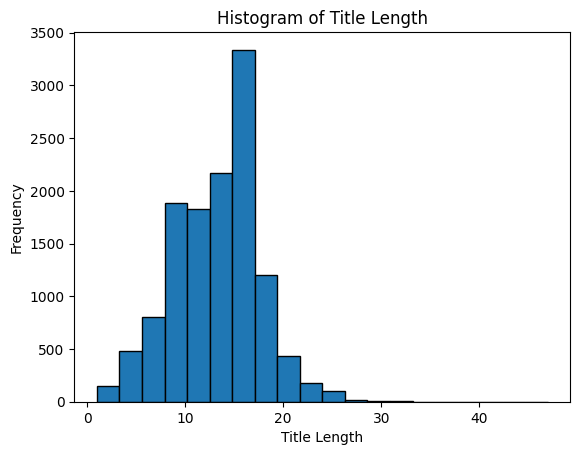

In [25]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

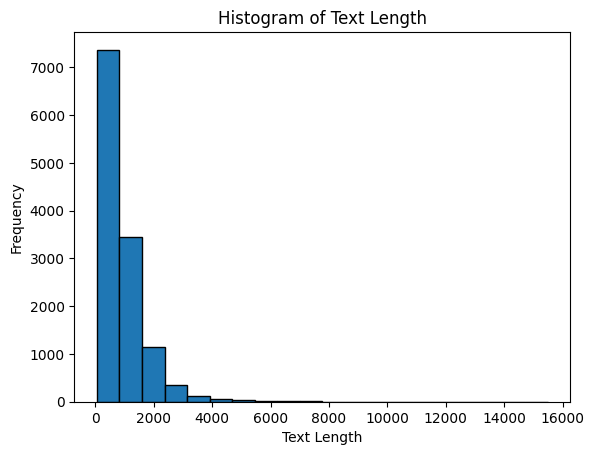

In [26]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

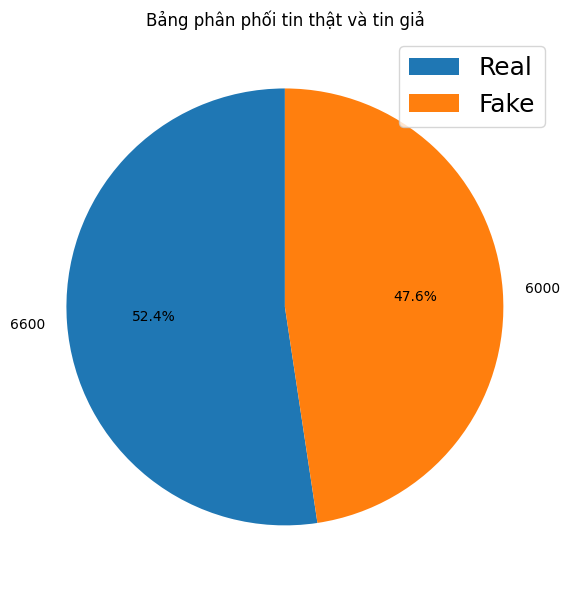

In [27]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [28]:
len_title_sum=0

for i in data_df['title']:
    len_word=i.split()
    len_title_sum += len(len_word)

avg_title=len_title_sum/data_df['title'].count()

avg_title

13.282619047619047

**Độ dài lớn nhất của tiêu đề**

In [29]:
max_title_len=0
for i in data_df['title']:
    len_word = i.split()
    if len(len_word) > max_title_len:
        max_title_len = len(len_word)
max_title_len

47

**Độ dài nhỏ nhất của tiêu đề**

In [30]:
min_title_len=max_title_len
for i in data_df['title']:
    len_word=i.split()
    if len(len_word) < min_title_len:
        min_title_len = len(len_word)

min_title_len

1

**Chiều dài trung bình text của 1 tin tức**

In [31]:
len_text_sum=0

for i in data_df['text']:
    len_word=i.split()
    len_text_sum += len(len_word)

avg_text=len_text_sum/data_df['text'].count()

avg_text

913.5705555555555

**Độ dài lớn nhất của text**

In [32]:
max_text_len=0

for i in data_df['text']:
    len_word=i.split()
    if len(len_word)>max_text_len:
        max_text_len=len(len_word)

max_text_len

15495

**Độ dài nhỏ nhất của text**

In [33]:
min_text_len = max_text_len

for i in data_df['text']:
    len_word=i.split()
    if len(len_word) < min_text_len:
        min_text_len = len(len_word)

min_text_len

52

**Tổng số từ trong title**

In [34]:
total_words = data_df['title'].str.split().map(len).sum()
total_words

167361

**Tổng số từ trong text**

In [35]:
total_words = data_df['text'].str.split().map(len).sum()
total_words

11510989

**Số từ khác biệt trong title**

In [36]:
unique_words = len(set(' '.join(data_df['title']).split()))
unique_words

11752

**Số từ khác biệt trong text**

In [37]:
unique_words = len(set(' '.join(data_df['text']).split()))
unique_words

115253

**Số từ khác biệt trong title và text**

In [38]:
combined_text = ' '.join(data_df['title']) + ' ' + ' '.join(data_df['text'])
unique_words_combined = len(set(combined_text.split()))
unique_words_combined

117203

# Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

**Thư viện để xử lý**

In [39]:
from pyvi import ViTokenizer

In [40]:
def wordopt(text):
    text = text.lower()
    text = re.sub('[%s]' % re.escape("""!–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…؛"""), ' ', text)
    text = re.sub('https?://\S+|www\.\S+|https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('\\W', ' ', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip()

    update_text = ""
    for word in text.split():
        if word not in stopwords:
            update_text += word+" "
        
    return update_text.strip()

In [41]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)

**Hợp nhất title và text**

In [42]:
data_df['article'] = data_df["title"] +' '+  data_df["text"] 

In [43]:
data_df.head(1)

,title,text,label,title_length,text_length,article
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1,5,954,Lưỡi gỗ Nguyễn Viết Thông Hội đồng lý luận tru...


**Áp dụng các xử lý dữ liệu**

In [44]:
data_df['Compound_Content'] = data_df['article'].apply(tokenizerVN)

In [45]:
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(wordopt)

In [46]:
data_df.head(1)

,title,text,label,title_length,text_length,article,Compound_Content,Compound_Content_SW
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1,5,954,Lưỡi gỗ Nguyễn Viết Thông Hội đồng lý luận tru...,Lưỡi gỗ Nguyễn Viết Thông Hội_đồng lý_luận tru...,lưỡi gỗ nguyễn viết thông hội_đồng lý_luận tru...


In [47]:
total_words = data_df['Compound_Content_SW'].str.split().map(len).sum()
total_words

4333077

In [48]:
unique_words_combined = len(set(' '.join(data_df['Compound_Content_SW']).split()))
unique_words_combined

92854

In [49]:
data_df.sample(10)

,title,text,label,title_length,text_length,article,Compound_Content,Compound_Content_SW
4522,Hãy thôi cúi mặt,Tôi sinh ra trong thời chinh chiến Nối tiếp ch...,1,4,292,Hãy thôi cúi mặt Tôi sinh ra trong thời chinh ...,Hãy thôi cúi mặt Tôi sinh ra trong thời chinh_...,cúi mặt sinh thời chinh_chiến nối_tiếp cha_ông...
8933,Kẻ ngáo đá ném bé trai 3 tuổi xuống kênh lĩnh ...,Ngày 29/8 TAND tỉnh Tiền Giang xét xử sơ thẩm ...,0,14,304,Kẻ ngáo đá ném bé trai 3 tuổi xuống kênh lĩnh ...,Kẻ ngáo đá ném bé trai 3 tuổi xuống kênh lĩnh ...,kẻ ngáo đá ném bé trai kênh lĩnh tù tand tỉnh ...
5437,Dàn cảnh va chạm giao thông để trộm điện thoại...,Ngày 30/8 Công an TP Hà Nội cho biết Phòng Cản...,0,13,307,Dàn cảnh va chạm giao thông để trộm điện thoại...,Dàn_cảnh va_chạm giao_thông để trộm điện_thoại...,dàn_cảnh va_chạm giao_thông trộm điện_thoại hà...
12177,Nguyên nhân khiến tàu Cát Linh - Hà Đông đang ...,. Báo điện tử VTC News dẫn thông tin từ Sở GTV...,0,17,510,Nguyên nhân khiến tàu Cát Linh - Hà Đông đang ...,Nguyên_nhân khiến tàu Cát_Linh - Hà_Đông đang ...,nguyên_nhân tàu cát_linh hà_đông chạy dừng đột...
7009,Công an ập vào rạp chiếu phim Mai 18+ để kiểm ...,Một người chơi TikTok đã đăng tải video ghi lạ...,1,15,1335,Công an ập vào rạp chiếu phim Mai 18+ để kiểm ...,Công_an ập vào rạp chiếu_phim Mai 18 + để kiểm...,công_an ập rạp chiếu_phim mai kiểm_tra khán_gi...
8619,Phó thủ tướng: Huy động mọi nguồn lực chống sạ...,Là vựa lúa lớn nhất nước nhưng ĐBSCL dễ tổn th...,0,13,801,Phó thủ tướng: Huy động mọi nguồn lực chống sạ...,Phó_thủ_tướng : Huy_động mọi nguồn_lực chống s...,phó_thủ_tướng huy_động nguồn_lực chống sạt_lở ...
266,Ông Nguyễn Phước Lộc tái đắc cử Chủ tịch Ủy ba...,Trước đó ngày 3/7 tại Hội nghị lần thứ 13 khóa...,0,18,379,Ông Nguyễn Phước Lộc tái đắc cử Chủ tịch Ủy ba...,Ông Nguyễn_Phước_Lộc tái đắc_cử Chủ_tịch Ủy_ba...,nguyễn_phước_lộc tái đắc_cử chủ_tịch ủy_ban mặ...
10454,Phải chăng Hoa Kỳ nghi ngờ về thực tâm của Việ...,Truyền thông quốc tế đưa tin vào giờ chót Tổng...,1,23,796,Phải chăng Hoa Kỳ nghi ngờ về thực tâm của Việ...,Phải_chăng Hoa_Kỳ nghi_ngờ về thực_tâm của Việ...,hoa_kỳ nghi_ngờ thực_tâm việt_nam phát_triển q...
11392,BÁO CHÍ ĐÁNH DOANH NGHIỆP (Dương Quốc Chính),Báo chí cách mạng bây giờ sống bằng tiền quảng...,1,8,481,BÁO CHÍ ĐÁNH DOANH NGHIỆP (Dương Quốc Chính) B...,BÁO_CHÍ ĐÁNH DOANH_NGHIỆP ( Dương_Quốc Chính )...,báo_chí đánh doanh_nghiệp dương_quốc báo_chí c...
11020,Tiếng Tàu được sử dụng như ngôn ngữ thứ hai tạ...,Học viện tư pháp có trụ sở chính tại đường Trầ...,1,15,197,Tiếng Tàu được sử dụng như ngôn ngữ thứ hai tạ...,Tiếng Tàu được sử_dụng như ngôn_ngữ thứ hai tạ...,tiếng tàu ngôn_ngữ hai học_viện tư_pháp học_vi...


In [50]:
from collections import Counter

In [51]:
word_counts_per_document = []

# Duyệt qua từng tài liệu
for doc in data_df['Compound_Content_SW']:
    words_in_doc = set(doc.split())  # Sử dụng set để loại bỏ từ trùng trong mỗi tài liệu
    word_counts_per_document.append(words_in_doc)

# Bước 4: Đếm tổng số lần xuất hiện của các từ trong tất cả các tài liệu (mỗi từ chỉ tính một lần trong một tài liệu)
total_word_counts = Counter()

# Duyệt qua danh sách các từ trong từng tài liệu và cập nhật tổng số đếm
for word_set in word_counts_per_document:
    total_word_counts.update(word_set)

In [52]:
print(len(total_word_counts))
for word, count in total_word_counts.most_common():
    print(f"{word}: {count/len(data_df)}")


92854
đi: 0.5247619047619048
dân: 0.5038888888888889
việt_nam: 0.5021428571428571
hai: 0.4897619047619048
tổ_chức: 0.3807936507936508
tỉnh: 0.3696031746031746
vụ: 0.3649206349206349
đầu: 0.3551587301587302
ảnh: 0.3504761904761905
đường: 0.34753968253968254
công_an: 0.34095238095238095
xã_hội: 0.3406349206349206
cơ_quan: 0.3372222222222222
lãnh_đạo: 0.33214285714285713
hàng: 0.33055555555555555
đảng: 0.3283333333333333
viết: 0.31055555555555553
đồng: 0.3103174603174603
thông_tin: 0.30857142857142855
quốc_gia: 0.30817460317460316
nhà_nước: 0.30126984126984124
khu_vực: 0.29833333333333334
hà_nội: 0.29753968253968255
xảy: 0.2930952380952381
hoạt_động: 0.28539682539682537
tiền: 0.28269841269841267
kinh_tế: 0.2776190476190476
chủ_tịch: 0.2735714285714286
chính_trị: 0.2729365079365079
xây_dựng: 0.26976190476190476
triệu: 0.2652380952380952
nhân_dân: 0.25817460317460317
huyện: 0.2573015873015873
phát_triển: 0.25595238095238093
chính_phủ: 0.24968253968253967
tp: 0.24682539682539684
báo: 0.24380

# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [ ]:
def tokenize(sentence):
    return tokenizerVN(sentence).split()

**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [54]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [55]:
# model_vector_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_vectorizer_CV.joblib")
# model_RFC_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_RFC_model_CV.joblib")

In [56]:
model_vector_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_vectorizer_TF.joblib")
# model_RFC_TF = os.path.join("../../Vector/Vietnamese/TF", "Vietnamese_RFC_model_TF.joblib")

In [57]:
# model_vector_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_vectorizer_W2V.joblib")
# model_RFC_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_RFC_model_W2V.joblib")

In [58]:
# model_vector_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_vectorizer_D2V.joblib")
# model_RFC_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_RFC_model_D2V.joblib")

## Các mô hình vector 

**CountVectorizer**

In [59]:
vectorizerCV = CountVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=0.001,          
                            max_df=0.5,            
                            max_features=12000,              
                            ngram_range=(1, 3)        
                            )

In [60]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

**TfidfVectorizer**

In [61]:
vectorizerTF = TfidfVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=0.001,          
                            max_df=0.5,            
                            max_features=12000, 
                            use_idf=True, 
                            ngram_range=(1,3)
                            )

In [62]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

**Word2Vec**

In [63]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [64]:
# Train the Word2Vec model on the tokenized training sentences
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=20
)

In [65]:
# Function to calculate the average Word2Vec vector for each sentence
def sentence_vector(sentence, model):
    # Get vectors for words in the sentence if they exist in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        # Calculate the mean of the word vectors for the sentence
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words in the sentence are in the vocabulary
        return np.zeros(model.vector_size)

In [66]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

**Doc2Vec**

In [67]:
def preprocess(doc):
    tokens = tokenize(doc)
    return [word for word in tokens if word not in stopwords]

In [68]:
documents = [TaggedDocument(preprocess(doc), [i]) for i, doc in enumerate(X_train)]

In [69]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [70]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_test]

## Save model

In [71]:
# joblib.dump(vectorizerCV, model_vector_CV)
joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

['../../Vector/Vietnamese\\Vietnamese_vectorizer_TF.joblib']

# Bước 1: Thuật toán RFC

## Áp dụng các cách vector với RFC

In [72]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

**CountVectorizer**

In [73]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

**tfidfVectorizer**

In [74]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

**Word2Vec**

In [75]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

**Doc2Vec**

In [76]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

## Đánh giá mô hình

**Vẽ hình**

In [77]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

In [78]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

**Tính toán đánh giá**

In [79]:
def evaluate_model(y_true, y_pred, name_model, save=False):
    
    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }

    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation_metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/VietNamese", f"Vietnamese_Evaluate_{name_model}.csv")
        metrics_df.to_csv(path_evaluate, index=False)

## Kết quả các model

### CountVectorizer

0.9774603174603175
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1605
           1       0.97      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



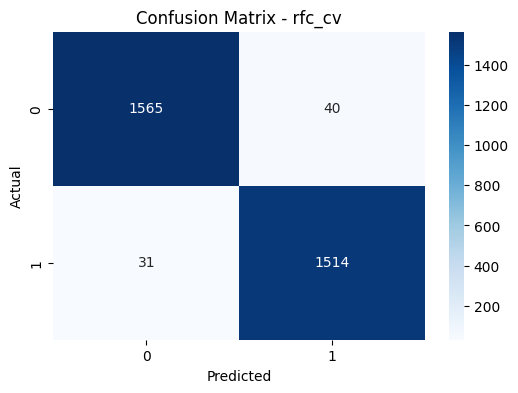

In [80]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv", save=True)

### TfidfVectorizer 

0.9812698412698413
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1605
           1       0.98      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



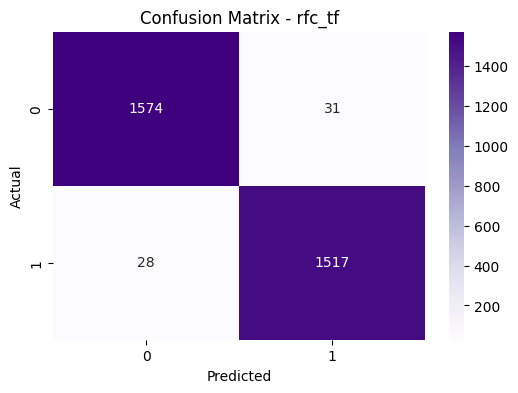

In [81]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf", save=True)

### Word2Vec

0.9657142857142857
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1605
           1       0.97      0.96      0.96      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



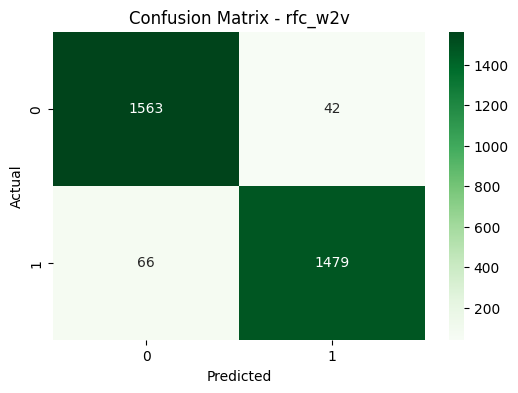

In [82]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v", save=True)


## Doc2Vec

0.9441269841269841
-------------------

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1605
           1       0.93      0.96      0.94      1545

    accuracy                           0.94      3150
   macro avg       0.94      0.94      0.94      3150
weighted avg       0.94      0.94      0.94      3150

-------------------



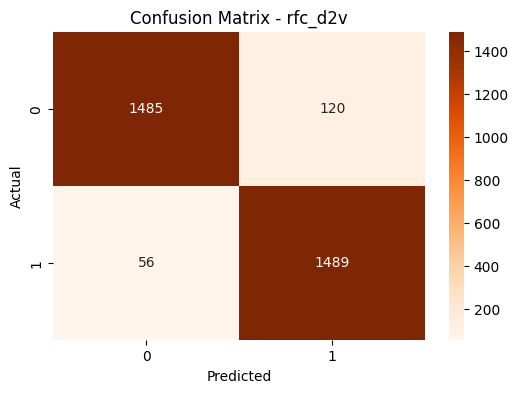

In [83]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v", save=True)

*Save model RFC*

In [84]:
# joblib.dump(rfc_cv, model_RFC_CV)
# joblib.dump(rfc_tf, model_RFC_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(rfc_d2v, model_RFC_D2V)

# Bước 2:Vector hóa TF-IDF

## Navie bayes

In [85]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)

0.9495238095238095
-------------------

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1605
           1       0.94      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



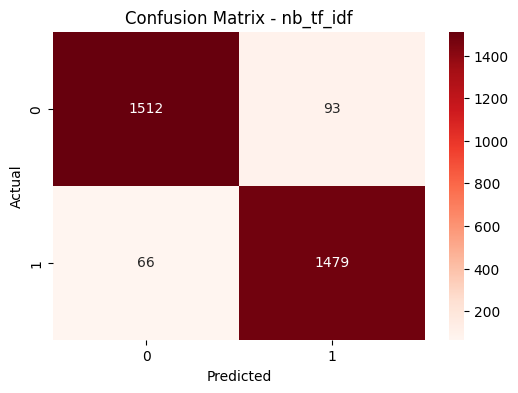

In [86]:
accuracy = accuracy_score(y_test, y_pred_nb) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_nb))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_nb,name_model="nb_tf_idf")

## DecisionTree

In [87]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)

0.920952380952381
-------------------

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1605
           1       0.93      0.91      0.92      1545

    accuracy                           0.92      3150
   macro avg       0.92      0.92      0.92      3150
weighted avg       0.92      0.92      0.92      3150

-------------------



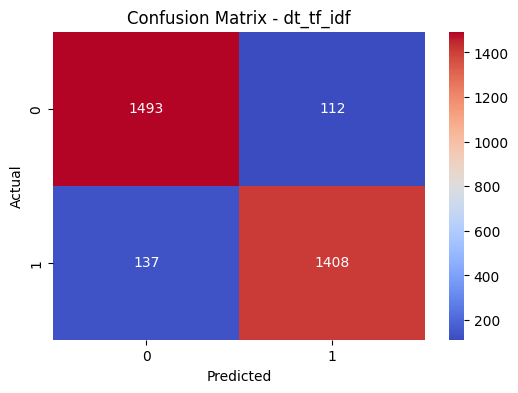

In [88]:
accuracy = accuracy_score(y_test, y_pred_dt) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_dt))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_dt,name_model="dt_tf_idf")

## RandomForest

In [89]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)

0.9812698412698413
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1605
           1       0.98      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



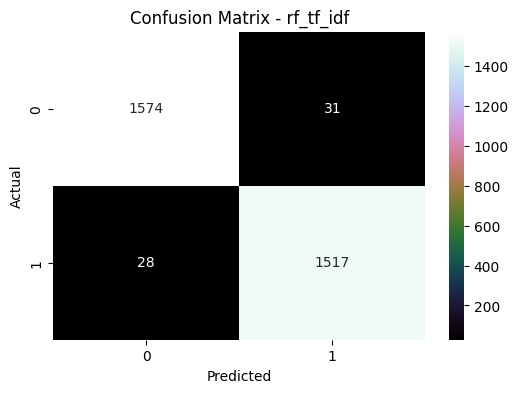

In [90]:
accuracy = accuracy_score(y_test, y_pred_rf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_rf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_rf,name_model="rf_tf_idf")

## SVM

In [91]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)

0.9822222222222222
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1605
           1       0.99      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



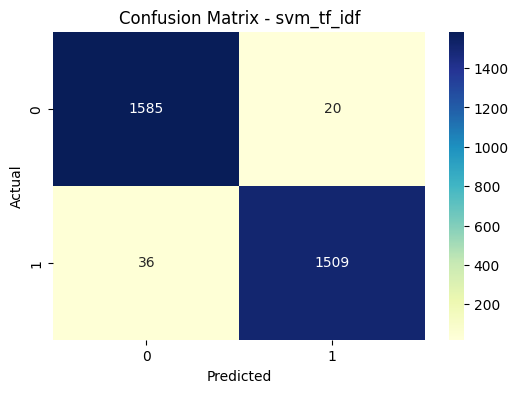

In [92]:
accuracy = accuracy_score(y_test, y_pred_svm) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_svm))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_svm,name_model="svm_tf_idf")

In [93]:
model_SVM_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_SVM_model_TF.joblib")
joblib.dump(svm_model, model_SVM_TF)

['../../Vector/Vietnamese\\Vietnamese_SVM_model_TF.joblib']

## LogisticRegression

In [94]:
lr_model = LogisticRegression()
lr_model.fit(Xv_trainTF, y_train)
y_pred_lr = lr_model.predict(Xv_testTF)

0.9733333333333334
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1605
           1       0.98      0.96      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



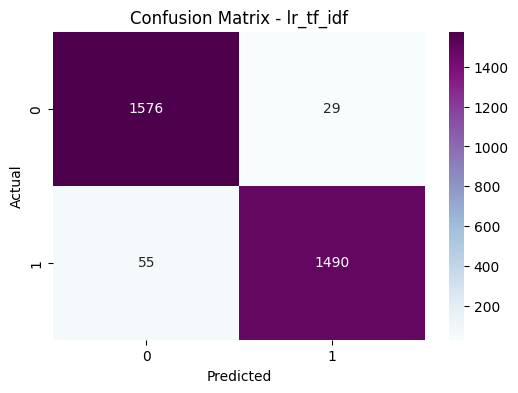

In [95]:
accuracy = accuracy_score(y_test, y_pred_lr) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_lr))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_lr,name_model="lr_tf_idf")

## GradientBoostingClassifier

In [96]:
gbc_model = GradientBoostingClassifier(random_state=0)
gbc_model.fit(Xv_trainTF, y_train)
y_pred_gbc = gbc_model.predict(Xv_testTF)

0.9619047619047619
-------------------

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1605
           1       0.96      0.97      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



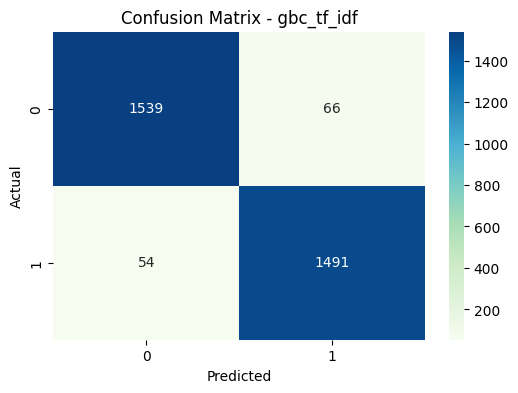

In [97]:
accuracy = accuracy_score(y_test, y_pred_gbc) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_gbc,name_model="gbc_tf_idf")

**save**

In [98]:
model_SVM_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_SVM_model_TF.joblib")
joblib.dump(svm_model, model_SVM_TF)

['../../Vector/Vietnamese\\Vietnamese_SVM_model_TF.joblib']

In [99]:
model_RFC_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_RFC_model_TF.joblib")
joblib.dump(rf_model, model_RFC_TF)

['../../Vector/Vietnamese\\Vietnamese_RFC_model_TF.joblib']